In [3]:
import numpy as np
import matplotlib.pyplot as plt

def runge(x):
    return 1.0 / (1.0 + 25.0 * x**2)

def design_matrix(x, degree, intercept=True):
    # polynomial features [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

rng = np.random.default_rng(2026)
n = 350
sigma = 0.25                                  # noise level: explore it!
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)
xx = np.linspace(-1, 1, n)


# Skalering av Y

In [9]:
# Your code for part a) here
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

maxdeg = 15
deg_V = np.arange(maxdeg + 1)
MSE_V = []
R2_V = []
Parameter_V = []
Prediction_V = []

for degree in range(maxdeg + 1):
    X = design_matrix(x, degree)
    X_train, X_test, y_train, y_test = train_test_split(X,
    y, test_size=0.3, random_state=2026)

    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    # Konstantkolonnen skal fortsatt være lik 1.
    mean[0] = 0.0
    std[0] = 1.0
    X_train_c = (X_train - mean) / std
    X_test_c = (X_test - mean) / std
    # y - Centrering
    y_mean = y_train.mean(axis=0)
    y_train_c = y_train - y_mean

    theta = np.linalg.pinv(X_train_c) @ y_train_c
    Parameter_V.append(theta)

    # Bruk treningsmodellens normalisering for hver grads prediksjonskurve.

    X_plot = design_matrix(xx, degree)
    X_plot_scaled = (X_plot - mean) / std
    Prediction_V.append(X_plot_scaled @ theta + y_mean)

    y_predict = X_test_c @ theta + y_mean
    mse = np.mean((y_test - y_predict)**2)
    MSE_V.append(mse)

    y_test_mean = np.mean(y_test)
    R2 = 1 - (np.sum((y_test - y_predict)**2))/(np.sum((y_test - y_test_mean)**2))
    R2_V.append(R2)

OLS_5D_theta = Parameter_V[5]
print(OLS_5D_theta)

[ 9.14598467e-17  6.18242189e-02 -7.05686127e-01 -2.32069935e-01
  5.12427625e-01  1.71212063e-01]


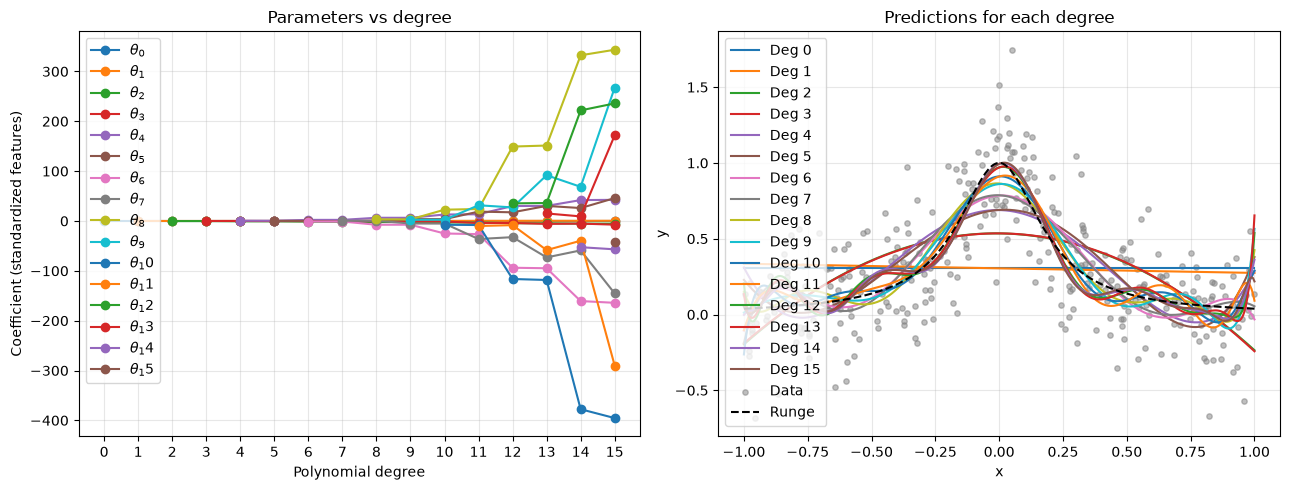

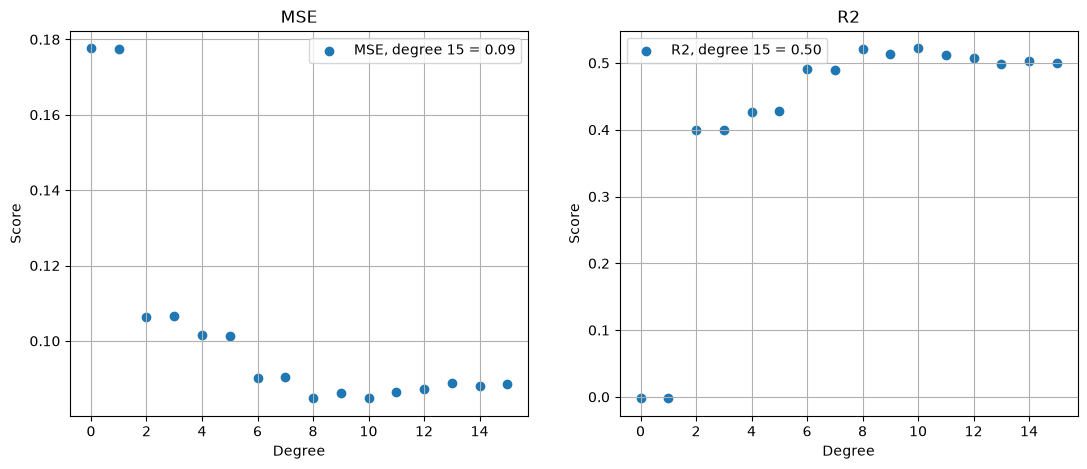

In [8]:
fig, (ax_parameters, ax_predictions) = plt.subplots(1, 2, figsize=(13, 5))

# Grad d har d + 1 parametre. NaN markerer parametre modellen ikke har.
parameters = np.full((maxdeg + 1, maxdeg + 1), np.nan)
for degree, theta in enumerate(Parameter_V):
    parameters[degree, :len(theta)] = theta
    ax_predictions.plot(xx, Prediction_V[degree], label=f"Deg {degree}")

for j in range(maxdeg + 1):
    ax_parameters.plot(deg_V, parameters[:, j], marker="o", label=rf"$\theta_{j}$")

ax_parameters.set(title="Parameters vs degree", xlabel="Polynomial degree",
                  ylabel="Coefficient (standardized features)")
ax_parameters.set_xticks(deg_V)
ax_parameters.legend()
ax_parameters.grid(alpha=0.3)

ax_predictions.scatter(x, y, s=15, color="gray", alpha=0.5, label="Data")
ax_predictions.plot(xx, runge(xx), "k--", label="Runge")
ax_predictions.set(title="Predictions for each degree", xlabel="x", ylabel="y")
ax_predictions.legend()
ax_predictions.grid(alpha=0.3)
fig.tight_layout()
#plt.ylim(-0.25,1.1)
plt.show()

#  R2 og MSE
fix, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))
ax1.scatter(deg_V, MSE_V, label = f"MSE, degree {maxdeg} = {MSE_V[-1]:.2f}")
ax2.scatter(deg_V, R2_V, label = f"R2, degree {maxdeg} = {R2_V[-1]:.2f}")
ax1.set_xlabel("Degree"), ax1.set_ylabel("Score")
ax2.set_xlabel("Degree"), ax2.set_ylabel("Score")
ax1.legend(), ax2.legend()
ax1.grid(), ax2.grid()
ax1.set_title("MSE"), ax2.set_title("R2")
plt.show()